# Stability of an equilibrium

The shipped QH case on a CPU, start to finish: load an equilibrium, build the basis, solve for
the growth rate, read the sign, look at the mode, and check the solve. About four minutes on one
CPU core; nothing here needs DESC or a GPU.

agnimhd answers one question about an equilibrium: the squared growth rate `gamma^2` of its most
unstable finite-n ideal MHD mode. **Positive means unstable.**

In [1]:
from pathlib import Path
import json
import numpy as np
import agnimhd

ROOT = Path(agnimhd.__file__).resolve().parents[2]   # the repository root
DATA = ROOT / "examples" / "data"
print(agnimhd.__version__)

0.1.0.dev0


## 1. Load an equilibrium

An `EquilibriumData` holds the metric, Jacobian, current and profiles of one equilibrium, sampled
on a grid of PEST coordinates `(rho, theta, zeta)` over one field period. This one was exported
from DESC at 24 x 12 x 8 nodes (`tools/export_desc_example.py`; its sidecar `.json` records how).
Any code can fill one ([Interface](../interface.md)).

In [2]:
eq = agnimhd.EquilibriumData.load(DATA / "qh_modprof_24x12x8.npz")
meta = json.loads((DATA / "qh_modprof_24x12x8.json").read_text())
print(eq.resolution, "nodes, NFP =", eq.NFP, ", minor radius a =", float(eq.a), "m")
print("pressure on axis", float(np.max(eq.p)), "Pa, iota from", float(eq.iota.min()), "to", float(eq.iota.max()))

(24, 12, 8) nodes, NFP = 4 , minor radius a = 1.7047332733412563 m


pressure on axis 428276.3706961554 Pa, iota from 1.020004681904769 to 1.0999648899144798


## 2. Build the basis

The `Basis` fixes the nodes and the derivative matrices. The radial nodes must be the ones the
equilibrium was exported on, here Legendre-Lobatto nodes through a map that clusters them near
`x_0 = 0.6`; a different radial basis would put the matrices on other nodes than the geometry and
give a wrong answer with no error ([Choosing options](../options.md)).

In [3]:
basis = agnimhd.Basis(*eq.resolution, radial="lobatto", automorphism=meta["automorphism"])
nodes, diffmat = basis.nodes_and_diffmat(eq.NFP)        # family 0: toroidal modes n = 0, 4, 8, ...
print(basis)

Basis(n_rho=24, n_theta=12, n_zeta=8, radial='lobatto', alpha=-0.35, beta=-0.65, automorphism={'eps': 0.01, 'x_0': 0.6, 'm_1': 2.5, 'm_2': 3.0}, mpol=None, ntor=None, zernike_penalty=0.05)


## 3. Solve

`growth_rate` returns `gamma^2`. With the default solver (`eigsh`, SciPy's ARPACK on the dense
matrix) this takes about half a minute here.

In [4]:
gamma2 = float(agnimhd.growth_rate(eq, diffmat))
print(f"gamma^2 = {gamma2:+.6e}  ->", "UNSTABLE" if gamma2 > 0 else "stable")
print(f"recorded at export: {-meta['reference_lambda']:+.6e}")

gamma^2 = +1.337527e-04  -> UNSTABLE
recorded at export: +1.337527e-04


`gamma^2` is in units of the Alfven frequency squared, `(v_A / a)^2`, with the field normalized to
`B_N = Psi / (pi a^2)` (see [Theory](../theory.md)). It is a small number, and its noise floor is
about 1e-10, so a value of 1e-4 is a clear instability.

## 4. The eigenpair, and how to check it

`eigenpair` also returns the eigenvector and the residual `|A v + gamma^2 v| / |gamma^2|`. The
residual is the quality measure: a small one means the pair is converged, whatever solver produced
it.

In [5]:
gamma2, v, residual = agnimhd.eigenpair(eq, diffmat)
print(f"gamma^2 = {gamma2:+.6e}, residual = {float(residual):.2e}, {v.shape[0]} unknowns")

gamma^2 = +1.337527e-04, residual = 6.38e-06, 6720 unknowns


## 5. Look at the mode

The eigenvector is the plasma displacement `xi`. `plot_eigenfunction_cross_sections` draws its
three components and `deltaV` in the `(R, Z)` plane at `zeta = 0` and `pi / NFP`; the `(R, Z)` of
the nodes come with the example data.

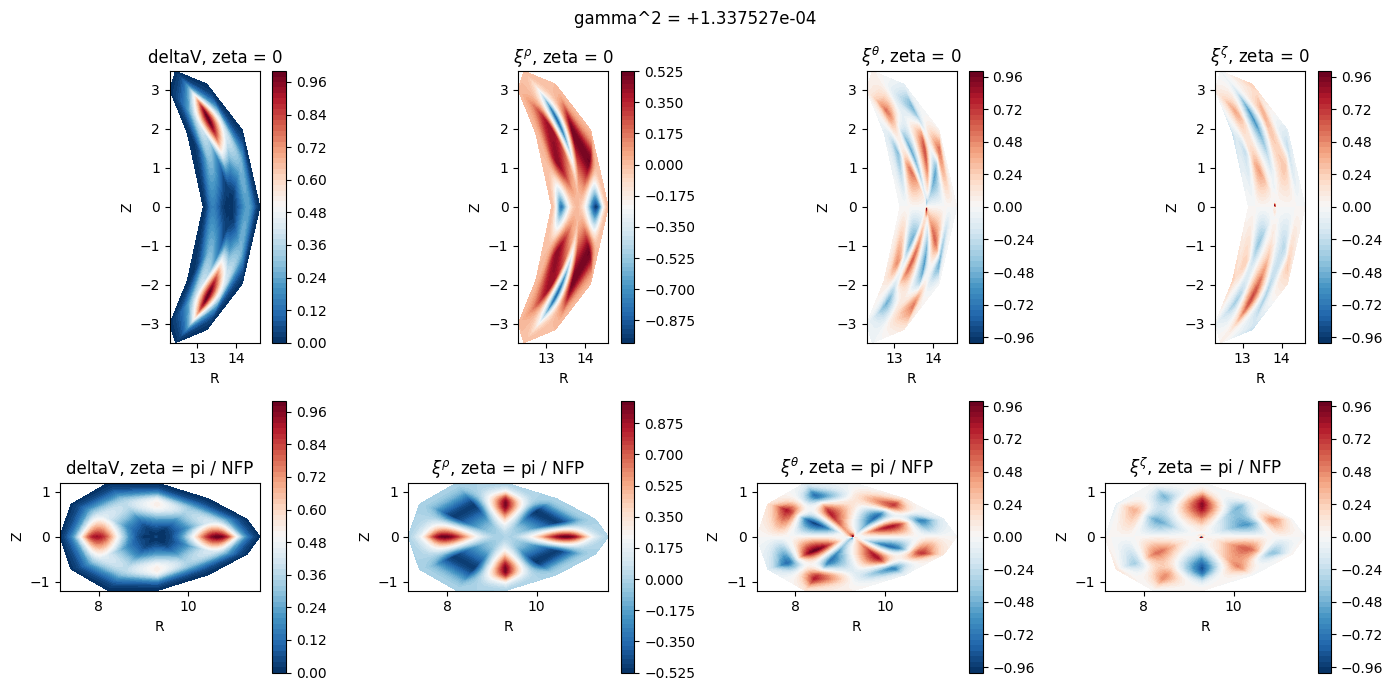

In [6]:
from agnimhd.assemble import matfree_operator
from agnimhd.plotting import plot_eigenfunction_cross_sections

geom = np.load(DATA / "qh_modprof_24x12x8_RZ.npz")
op = matfree_operator(eq, diffmat)
fig, axes = plot_eigenfunction_cross_sections(eq, op, np.asarray(v), gamma2, geom["R"], geom["Z"])
fig.set_size_inches(14, 7); fig.tight_layout()

## 6. Another solver: the dense GPU solver on a CPU

`eigensolver="dense"` factorizes the shifted matrix once (Cholesky) and runs Lanczos on it; it is the
solver for one GPU and works on a CPU too. It needs the shift `sigma` above the largest `gamma^2`
and not far above it. Here the eigsh value tells us where to put it.

In [7]:
dense = agnimhd.SolverConfig(eigensolver="dense", sigma=1.3 * float(gamma2))
g_dense, _, r_dense = agnimhd.eigenpair(eq, diffmat, solver=dense)
print(f"dense: gamma^2 = {float(g_dense):+.6e} (eigsh {gamma2:+.6e}), residual {float(r_dense):.1e}")

dense: gamma^2 = +1.337527e-04 (eigsh +1.337527e-04), residual 1.9e-07


## 7. Every toroidal mode family

The grid spans one field period, so one solve holds the modes `n = x + k NFP` of one family `x`.
The families together hold every `n`; the most unstable one is the answer for the equilibrium.
Family 1 (and 3, its conjugate) is a complex Hermitian problem and takes longer.

In [8]:
for x in basis.families(eq.NFP):
    g = float(agnimhd.growth_rate(eq, basis.nodes_and_diffmat(eq.NFP, family=x)[1]))
    print(f"family {x}: gamma^2 = {g:+.6e}")

family 0: gamma^2 = +1.337527e-04


family 1: gamma^2 = +1.349362e-04


family 2: gamma^2 = +1.641554e-04


## Where next

- `agnimhd solve eq.npz --radial lobatto --automorphism '{...}'` does sections 3 and 7 from the
  shell, and `agnimhd solve eq.h5 --res 24,12,8` evaluates a DESC file first.
- Larger cases: `eigensolver="jd"`, matrix-free, with its coarse level ([Choosing options](../options.md)).
- Optimization through DESC: `AgniStability` ([Home](../index.md#two-modes), `examples/desc_optimization.py`).